Employee Attrition Project using Superwised learning algorithm , Random Forest Tree

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.preprocessing import LabelEncoder
import joblib


STEP 1: LOAD THE DATASET

In [18]:
df=pd.read_csv("C:/Users/varsh/OneDrive - Malla Reddy Engineering College for Women/Desktop/JAVA/Project1/WA_Fn-UseC_-HR-Employee-Attrition.csv")
print(df.shape)
print(df["Attrition"].value_counts(normalize=True))

(1470, 35)
Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64


STEP 2: EDA

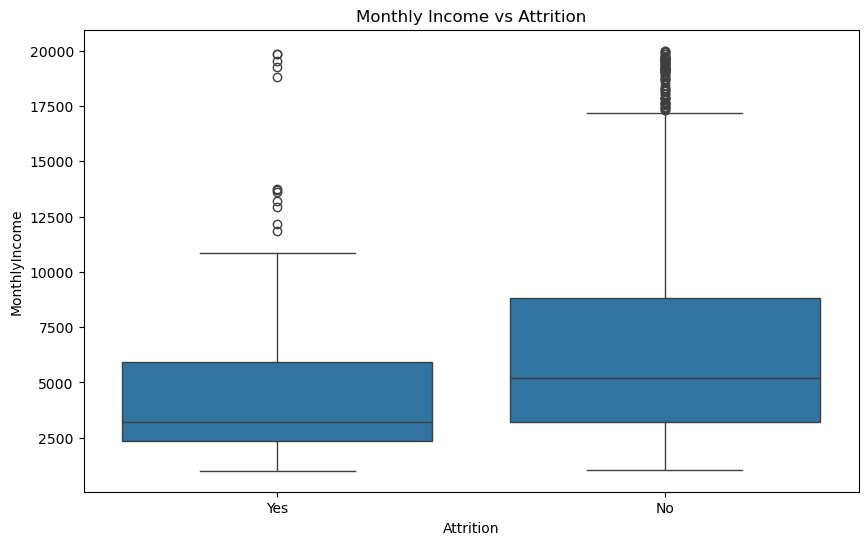

In [19]:
#plot : Income vs Attrition
plt.figure(figsize=(10,6))
sns.boxplot(x="Attrition",y="MonthlyIncome",data=df)
plt.title("Monthly Income vs Attrition")
plt.show()

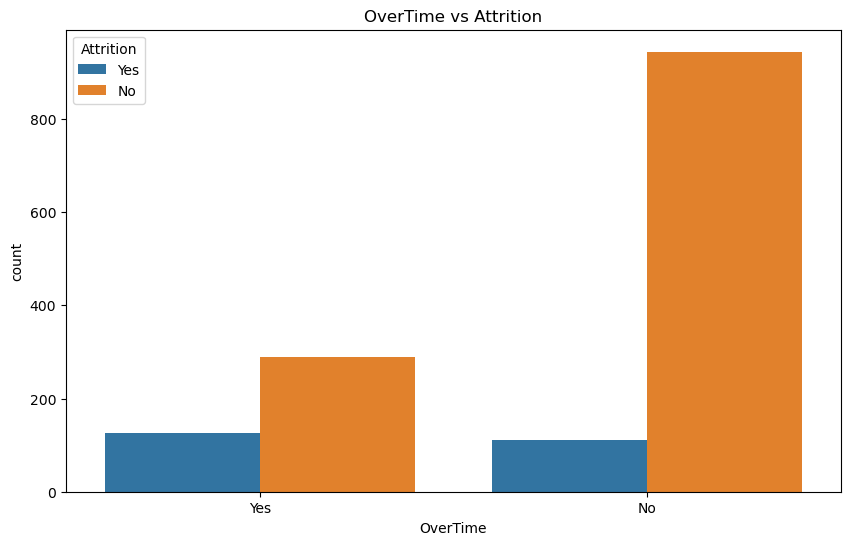

In [20]:

plt.figure(figsize=(10,6))
sns.countplot(x="OverTime",hue="Attrition",data=df)
plt.title("OverTime vs Attrition")
plt.show()

STEP 3 : DATA PREPROCESSING 

In [21]:
df.drop(columns=["EmployeeNumber","EmployeeCount","Over18","StandardHours"],inplace=True)
df.shape

(1470, 31)

In [22]:
encoders={}
for col in df.select_dtypes(include=["object"]).columns:
    lb=LabelEncoder()
    df[col]=lb.fit_transform(df[col])
    encoders[col]=lb

X=df.drop("Attrition",axis=1)
y=df["Attrition"]

X_train ,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

STEP 4 : MODELING AND TUNNING (HYPERPARAMETER)

In [23]:
rf=RandomForestClassifier(random_state=42)

param_grid={
    "n_estimators":[50,100],
    "max_depth":[10,20,None],
    "min_samples_split":[2,5],
    "min_samples_leaf":[1,2]
}

#GridSearchCV is computationally expensive , so we will use a smaller grid for
grid_search=GridSearchCV(rf,param_grid=param_grid,cv=5,scoring="f1")
grid_search.fit(X_train,y_train)

print("Best Parameters:",grid_search.best_params_)

Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}


STEP 5 : MODEL EVALUATION

In [24]:
best_model=grid_search.best_estimator_
predictions=best_model.predict(X_test)

print(classification_report(y_test,predictions))
print(confusion_matrix(y_test,predictions))

              precision    recall  f1-score   support

           0       0.88      0.99      0.93       255
           1       0.71      0.13      0.22        39

    accuracy                           0.88       294
   macro avg       0.80      0.56      0.58       294
weighted avg       0.86      0.88      0.84       294

[[253   2]
 [ 34   5]]


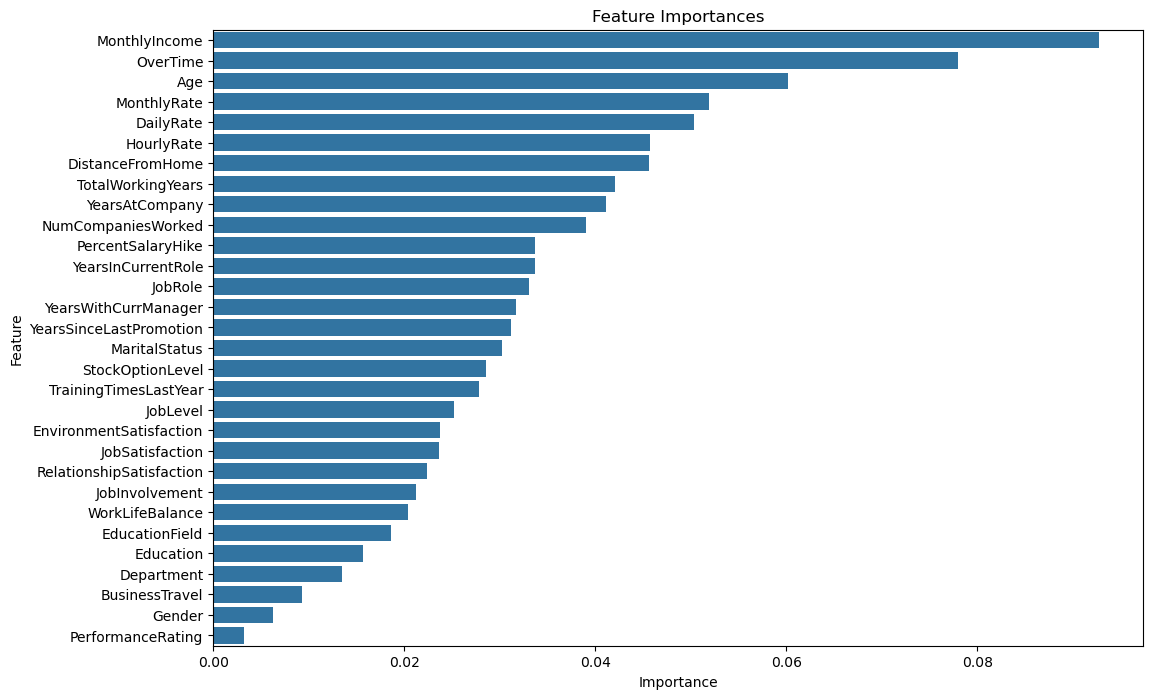

In [25]:
importances=pd.DataFrame({
    "Feature": X.columns,
    "Importance":best_model.feature_importances_
}).sort_values(by="Importance",ascending=False)

plt.figure(figsize=(12,8))
sns.barplot(x="Importance",y="Feature",data=importances)
plt.title("Feature Importances")
plt.show()

STEP 6 : SAVE THE MODEL

In [26]:
model=RandomForestClassifier(n_estimators=50,max_depth=20,min_samples_split=5,min_samples_leaf=1,random_state=42)
model.fit(X_train,y_train)

RandomForestClassifier(max_depth=20, min_samples_split=5, n_estimators=50,
                       random_state=42)

In [27]:
joblib.dump(model,"attrition_model.pkl")
joblib.dump(lb,"label_encoder.pkl")
joblib.dump(X.columns.to_list(),"feature_columns.pkl")

['feature_columns.pkl']